# Z-Distribution <hr style="border:2.5px solid rgb(28, 75, 147)"></hr>

<b>Sidney Louise G. Monillo</b>
<br><i>Computer Engineer/Technician</i>

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
# load dataset
df = pd.read_csv(r'datasets/transformer-voltage.csv', 
                 delimiter=",",
                 index_col='Sample')
df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [4]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [5]:
# summary of statistics
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [6]:
# z-critical for two-tailed tes
alpha = 0.05
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(1.959963984540054)

In [7]:
# confidence interval
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)

print("CI =", "[",  ci_lower, ",", ci_upper, "]")

CI = [ 118.50080585628282 , 122.07919414371713 ]


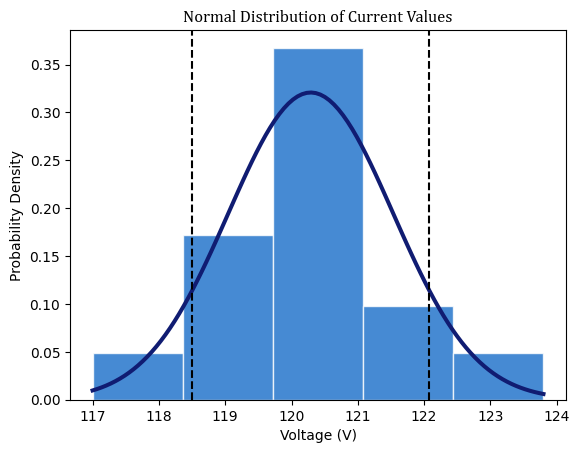

In [8]:
# voltage distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

# x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

# normal distribution plot
x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p,
        color="#101C72",
        linewidth=2.9)

# histogram
plt.hist(df['Voltage'], bins=5,
        density=True,
        alpha=0.8,
        color="#186DC8",
        edgecolor="white")

plt.title('Normal Distribution of Current Values',
            font = 'Cambria',
            fontsize = 12)
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

# confidence interval
plt.axvline(x = ci_lower,
            color='Black',
            linestyle='--')
plt.axvline(x = ci_upper,
            color='Black',
            linestyle='--')
plt.show()
